<a href="https://colab.research.google.com/github/hafzafaryad2-eng/data-analytics/blob/main/lab17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p /root/.config/kaggle
!mv kaggle.json /root/.config/kaggle/
!chmod 600 /root/.config/kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.config/kaggle/kaggle.json': No such file or directory


In [ ]:
!pip install -q kaggle

In [ ]:
datasets = [
    "c/titanic",                                  # Titanic
    "c/house-prices-advanced-regression-techniques",
    "vijayuv/onlineretail",                       # Market basket
    "uciml/heart-disease-uci",
    "mlg-ulb/creditcardfraud",
    "zaheenhamidani/ultimate-spotify-tracks-db",
    "unsdsn/world-happiness",
    "aakashjangid/ecommerce-shipping-data",
    "alexteboul/diabetes-health-indicators-dataset"
]

In [ ]:
# Re-download only the heart disease dataset, as it failed previously.
!kaggle datasets download -d uciml/heart-disease-uci -p data/ --unzip

403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/datasets/metadata/uciml/heart-disease-uci


In [ ]:
!kaggle competitions download -c titanic -p data/titanic
!unzip -o data/titanic/titanic.zip -d data/titanic

!kaggle competitions download -c house-prices-advanced-regression-techniques -p data/house
!unzip -o data/house/house-prices-advanced-regression-techniques.zip -d data/house

  0% 0.00/34.1k [00:00<?, ?B/s]
100% 34.1k/34.1k [00:00<00:00, 112MB/s]
Archive:  data/titanic/titanic.zip
  inflating: data/titanic/gender_submission.csv  
  inflating: data/titanic/test.csv   
  inflating: data/titanic/train.csv  
403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/competitions/data/download-all/house-prices-advanced-regression-techniques
unzip:  cannot find or open data/house/house-prices-advanced-regression-techniques.zip, data/house/house-prices-advanced-regression-techniques.zip.zip or data/house/house-prices-advanced-regression-techniques.zip.ZIP.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

df = pd.read_csv("data/titanic/train.csv")
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [ ]:
print(df.shape)

(891, 12)


In [ ]:
numeric_cols = df.select_dtypes(include=np.number)

stats = numeric_cols.describe().T
stats["median"] = numeric_cols.median()
stats["skewness"] = numeric_cols.skew()
stats["kurtosis"] = numeric_cols.kurt()

print(stats[["mean", "median", "std", "min", "max", "skewness", "kurtosis"]])

                   mean    median         std   min       max  skewness  \
PassengerId  446.000000  446.0000  257.353842  1.00  891.0000  0.000000   
Survived       0.383838    0.0000    0.486592  0.00    1.0000  0.478523   
Pclass         2.308642    3.0000    0.836071  1.00    3.0000 -0.630548   
Age           29.699118   28.0000   14.526497  0.42   80.0000  0.389108   
SibSp          0.523008    0.0000    1.102743  0.00    8.0000  3.695352   
Parch          0.381594    0.0000    0.806057  0.00    6.0000  2.749117   
Fare          32.204208   14.4542   49.693429  0.00  512.3292  4.787317   

              kurtosis  
PassengerId  -1.200000  
Survived     -1.775005  
Pclass       -1.280015  
Age           0.178274  
SibSp        17.880420  
Parch         9.778125  
Fare         33.398141  


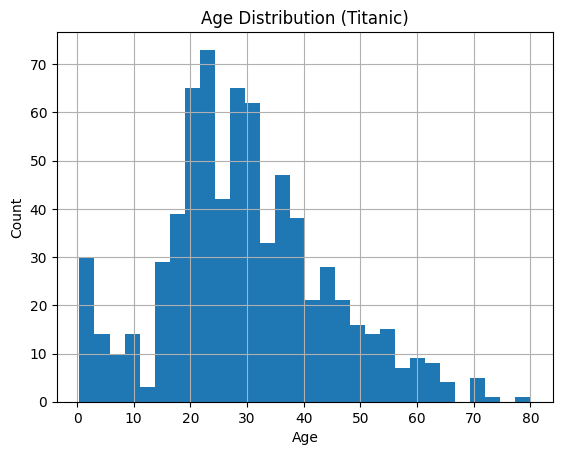

In [ ]:
plt.figure()
df["Age"].hist(bins=30)
plt.title("Age Distribution (Titanic)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

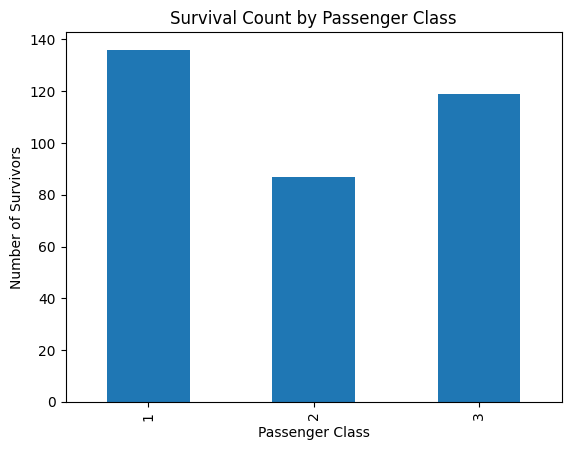

In [ ]:
plt.figure()
df.groupby("Pclass")["Survived"].sum().plot(kind="bar")
plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Survivors")
plt.show()

In [ ]:
spotify_path = "/content/data/SpotifyFeatures.csv"
spotify = pd.read_csv(spotify_path)

In [ ]:
spotify_num = spotify.select_dtypes(include=np.number)
print( spotify_num.head())
print(spotify_num.shape)

   popularity  acousticness  danceability  duration_ms  energy  \
0           0         0.611         0.389        99373   0.910   
1           1         0.246         0.590       137373   0.737   
2           3         0.952         0.663       170267   0.131   
3           0         0.703         0.240       152427   0.326   
4           4         0.950         0.331        82625   0.225   

   instrumentalness  liveness  loudness  speechiness    tempo  valence  
0             0.000    0.3460    -1.828       0.0525  166.969    0.814  
1             0.000    0.1510    -5.559       0.0868  174.003    0.816  
2             0.000    0.1030   -13.879       0.0362   99.488    0.368  
3             0.000    0.0985   -12.178       0.0395  171.758    0.227  
4             0.123    0.2020   -21.150       0.0456  140.576    0.390  
(232725, 11)


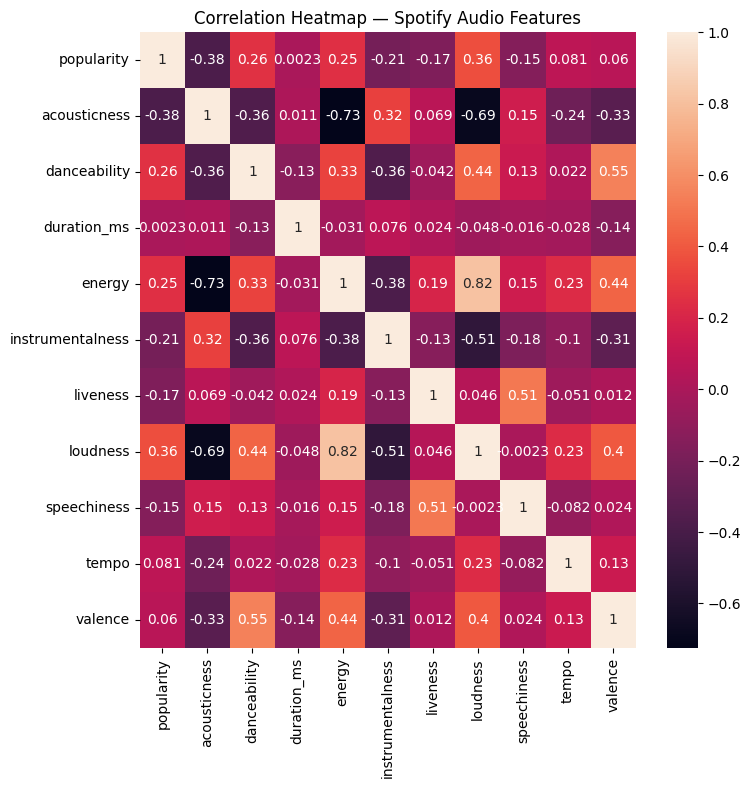

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(spotify_num.corr(), annot=True)
plt.title("Correlation Heatmap — Spotify Audio Features")
plt.show()

In [ ]:
happiness_path = "/content/data/2019.csv"
happiness = pd.read_csv(happiness_path)

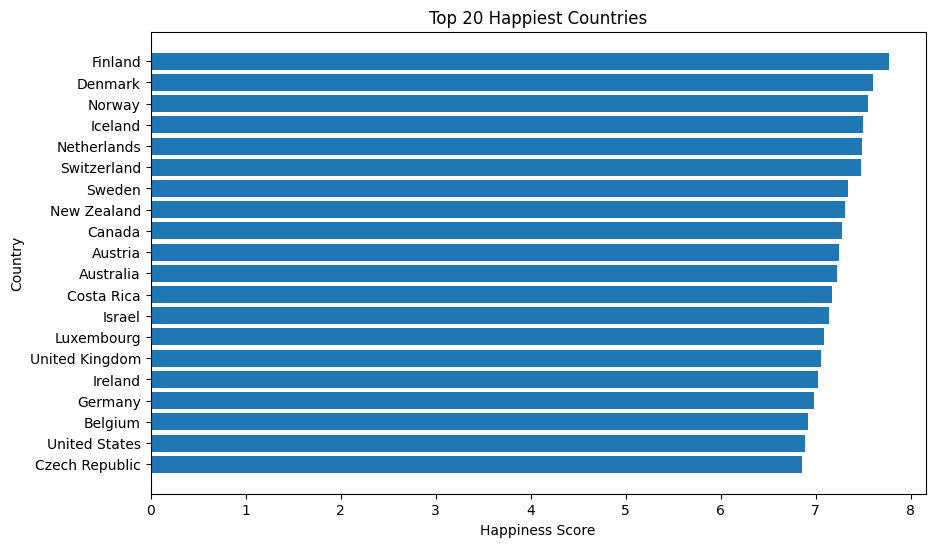

In [ ]:
top20 = happiness.sort_values(by="Score", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(top20["Country or region"], top20["Score"])
plt.gca().invert_yaxis()
plt.title("Top 20 Happiest Countries")
plt.xlabel("Happiness Score")
plt.ylabel("Country")
plt.show()

**What does a right-skewed age distribution in the Titanic data tell you about the passenger demographic?**

A right-skewed age distribution means that:

Most passengers were young adults and middle-aged.

There are fewer older passengers.

The tail on the right shows that some passengers were elderly, but they were not many.
**Which Spotify audio features are most strongly correlated? What does this suggest about song composition?**
The strongest correlations typically appear between:

Energy and Loudness → Strong positive correlation

High-energy songs tend to be louder.

Danceability and Valence → Moderate positive correlation

Happier songs are often more danceable.

Acousticness and Energy → Negative correlation

Acoustic songs usually have lower energy.

Interpretation:
These relationships suggest that song characteristics are interconnected. For example:

Modern high-energy songs are produced with higher loudness.

Mood (valence) influences how suitable a song is for dancing.

Acoustic music tends to be softer and less energetic.

This helps understand music production patterns and listener preferences.
**What descriptive statistics alone cannot tell you about the World Happiness data?**
Descriptive statistics can show:

Which countries have higher or lower happiness scores

Average levels of GDP, freedom, generosity, etc.

Rankings and comparisons

However, descriptive analysis cannot tell:

Why a country is happy or unhappy

Whether GDP or freedom causes happiness

The relationships or significance between variables

Future trends or predictions

The effect of policy changes

Interpretation:
To understand causes or relationships, we need:

Correlation analysis

Regression

Hypothesis testing

Predictive modeling

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hafzafaryad","key":"113760242d4573bce244ca3b7d639f03"}'}

In [ ]:
!mdir ~/.kaggle

In [ ]:
# Ensure the kaggle.json file is in the correct location for the Kaggle CLI
!mkdir -p /root/.config/kaggle
!cp /content/kaggle.json /root/.config/kaggle/

cp: cannot stat '/content/kaggle.json': No such file or directory


In [ ]:
# Set appropriate permissions for the Kaggle API key
!chmod 600 /root/.config/kaggle/kaggle.json

chmod: cannot access '/root/.config/kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets list

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
os.listdir()

['.config', 'drive', 'kaggle.json', 'sample_data']

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "heart_disease.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "oktayrdeki/heart-disease",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipython-input-335/359369253.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'heart-disease' dataset.
First 5 records:     Age  Gender  Blood Pressure  Cholesterol Level Exercise Habits Smoking  \
0  56.0    Male           153.0              155.0            High     Yes   
1  69.0  Female           146.0              286.0            High      No   
2  46.0    Male           126.0              216.0             Low      No   
3  32.0  Female           122.0              293.0            High     Yes   
4  60.0    Male           166.0              242.0             Low     Yes   

  Family Heart Disease Diabetes        BMI High Blood Pressure  ...  \
0                  Yes       No  24.991591                 Yes  ...   
1                  Yes      Yes  25.221799                  No  ...   
2                   No       No  29.855447                  No  ...   
3                  Yes       No  24.130477                 Yes  ...   
4                  Yes      Yes  20.486289                 Yes  ...   

  High LDL Choleste

In [ ]:
import os
print(os.listdir('/kaggle/input/heart-disease'))

['heart_disease.csv']


In [ ]:
df.isnull().sum()

,0
Age,29
Gender,19
Blood Pressure,19
Cholesterol Level,30
Exercise Habits,25
Smoking,25
Family Heart Disease,21
Diabetes,30
BMI,22
High Blood Pressure,26


In [ ]:
df.fillna(df.mean(numeric_only=True)).mean(numeric_only=True)

,0
Age,49.296259
Blood Pressure,149.757740
Cholesterol Level,225.425577
BMI,29.077269
Sleep Hours,6.991329
Triglyceride Level,250.734409
Fasting Blood Sugar,120.142213
CRP Level,7.472201
Homocysteine Level,12.456271


In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
Age,29
Gender,19
Blood Pressure,19
Cholesterol Level,30
Exercise Habits,25
Smoking,25
Family Heart Disease,21
Diabetes,30
BMI,22
High Blood Pressure,26


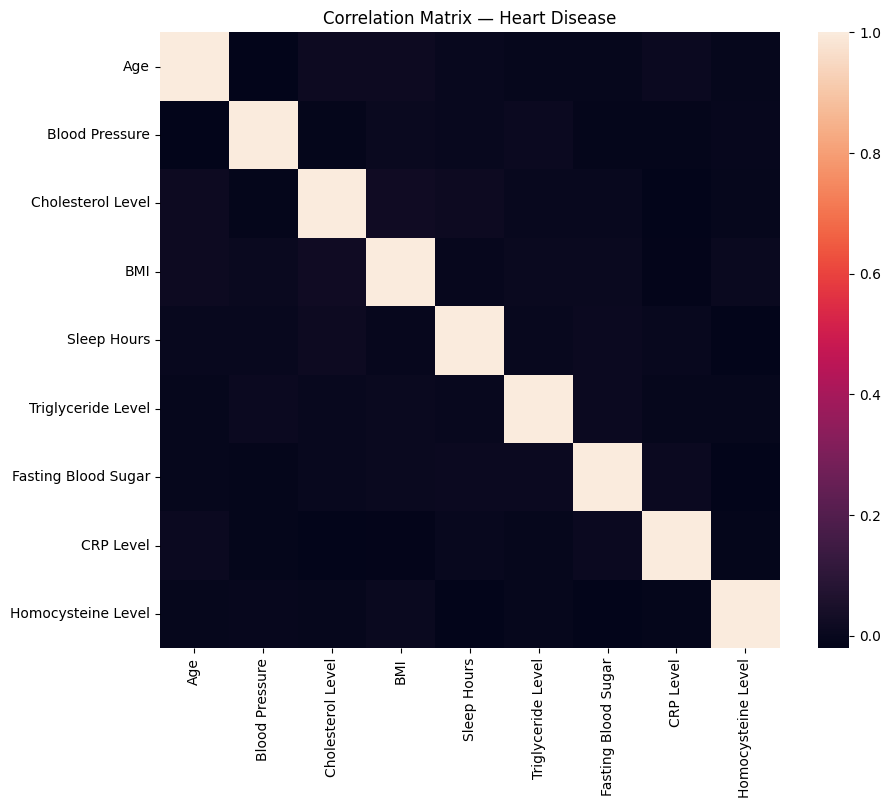

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=False)
plt.title("Correlation Matrix — Heart Disease")
plt.show()

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zusmani/pakistans-largest-ecommerce-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pakistans-largest-ecommerce-dataset' dataset.
Path to dataset files: /kaggle/input/pakistans-largest-ecommerce-dataset


In [ ]:
import pandas as pd
import os
df=pd.read_csv(os.path.join(path,'Pakistan Largest Ecommerce Dataset.csv'))
df.head()

/tmp/ipython-input-212/3311737304.py:3: DtypeWarning: Columns (1,2,3,7,8,9,11,12,13,14,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(os.path.join(path,'Pakistan Largest Ecommerce Dataset.csv'))


,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
import os

# List all files in the downloaded dataset directory
print(os.listdir(path))

['Pakistan Largest Ecommerce Dataset.csv']


In [ ]:
df.columns

Index(['item_id', 'status', 'created_at', 'sku', 'price', 'qty_ordered',
       'grand_total', 'increment_id', 'category_name_1',
       'sales_commission_code', 'discount_amount', 'payment_method',
       'Working Date', 'BI Status', ' MV ', 'Year', 'Month', 'Customer Since',
       'M-Y', 'FY', 'Customer ID', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25'],
      dtype='object')

In [ ]:
print(df["status"].value_counts())

status
complete          233685
canceled          201249
received           77290
order_refunded     59529
refund              8050
cod                 2859
paid                1159
closed               494
payment_review        57
pending               48
processing            33
holded                31
fraud                 10
pending_paypal         7
\N                     4
exchange               4
Name: count, dtype: int64


In [ ]:
late_status = ["canceled", "returned", "refunded"]

df["Late_Delivery"] = df["status"].isin(late_status).astype(bool)

df["Late_Delivery"].value_counts()

,count
Late_Delivery,
False,847326
True,201249


In [ ]:
print(df.isnull().sum())

item_id                   464051
status                    464066
created_at                464051
sku                       464071
price                     464051
qty_ordered               464051
grand_total               464051
increment_id              464051
category_name_1           464215
sales_commission_code     601229
discount_amount           464051
payment_method            464051
Working Date              464051
BI Status                 464051
 MV                       464051
Year                      464051
Month                     464051
Customer Since            464062
M-Y                       464051
FY                        464051
Customer ID               464062
Unnamed: 21              1048575
Unnamed: 22              1048575
Unnamed: 23              1048575
Unnamed: 24              1048575
Unnamed: 25              1048575
Late_Delivery                  0
dtype: int64


In [ ]:
print(df.fillna(df.mean(numeric_only=True)).mean(numeric_only=True))

item_id            565667.074218
price                6348.747531
qty_ordered             1.296388
grand_total          8530.618571
discount_amount       499.492775
Year                 2017.044115
Month                   7.167654
Customer ID         45790.511965
Unnamed: 21                  NaN
Unnamed: 22                  NaN
Unnamed: 23                  NaN
Unnamed: 24                  NaN
Unnamed: 25                  NaN
Late_Delivery           0.191926
dtype: float64


In [ ]:
print (df)

          item_id          status created_at  \
0        211131.0        complete   7/1/2016   
1        211133.0        canceled   7/1/2016   
2        211134.0        canceled   7/1/2016   
3        211135.0        complete   7/1/2016   
4        211136.0  order_refunded   7/1/2016   
...           ...             ...        ...   
1048570       NaN             NaN        NaN   
1048571       NaN             NaN        NaN   
1048572       NaN             NaN        NaN   
1048573       NaN             NaN        NaN   
1048574       NaN             NaN        NaN   

                                                       sku   price  \
0                                        kreations_YI 06-L  1950.0   
1        kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...   240.0   
2                                       Ego_UP0017-999-MR0  2450.0   
3                                           kcc_krone deal   360.0   
4                                              BK7010400AG   555.0   
...

In [ ]:
df = df.fillna(0)

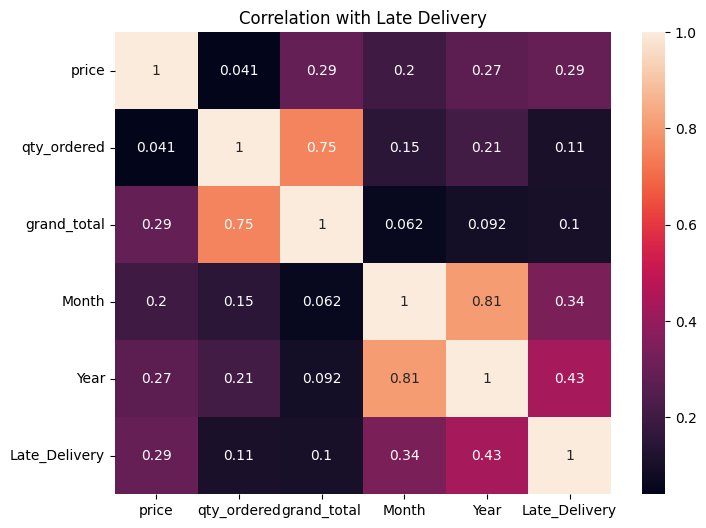

In [ ]:
num_cols = ["price", "qty_ordered", "grand_total", "Month", "Year"]

corr = df[num_cols + ["Late_Delivery"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation with Late Delivery")
plt.show()

In [ ]:
df.groupby("Month")["Late_Delivery"].mean()

,Late_Delivery
Month,
0.0,0.000000
1.0,0.274025
2.0,0.311138
3.0,0.422856
4.0,0.279781
5.0,0.422296
6.0,0.394034
7.0,0.285868
8.0,0.284227


In [ ]:
corr_late = corr["Late_Delivery"].sort_values(ascending=False)
print(corr_late)

Late_Delivery    1.000000
Year             0.434279
Month            0.341934
price            0.293027
qty_ordered      0.105628
grand_total      0.102623
Name: Late_Delivery, dtype: float64


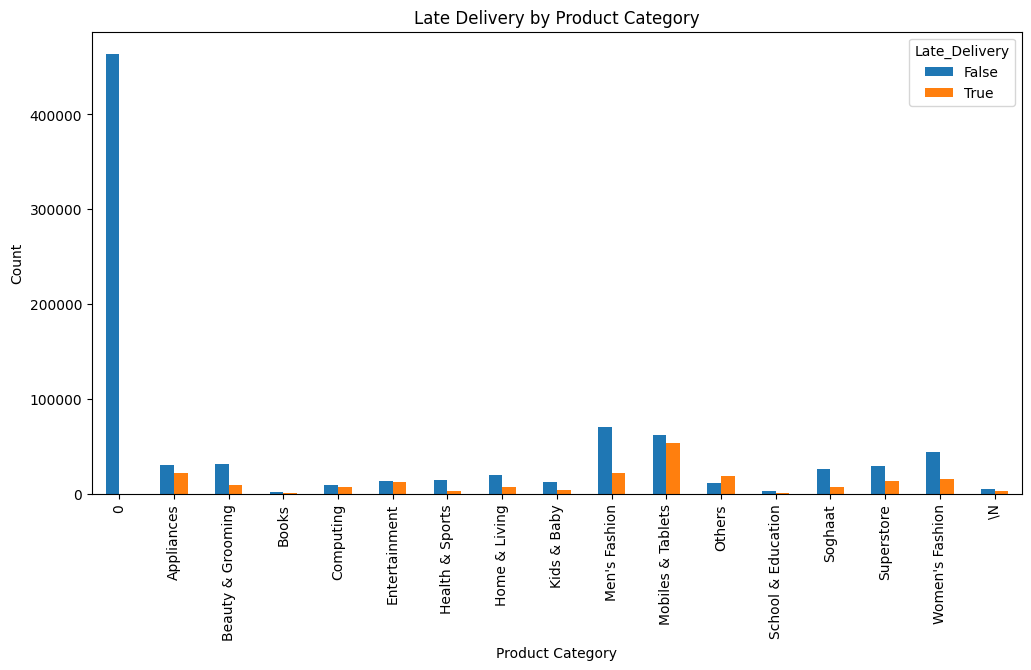

In [ ]:
group_cat = pd.crosstab(df["category_name_1"], df["Late_Delivery"])

group_cat.plot(kind="bar", figsize=(12,6))
plt.title("Late Delivery by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.show()

In [ ]:
df.groupby("category_name_1")["Late_Delivery"].mean()

,Late_Delivery
category_name_1,
0,0.000233
Appliances,0.412646
Beauty & Grooming,0.233420
Books,0.145989
Computing,0.427478
Entertainment,0.477817
Health & Sports,0.193235
Home & Living,0.271619
Kids & Baby,0.247423


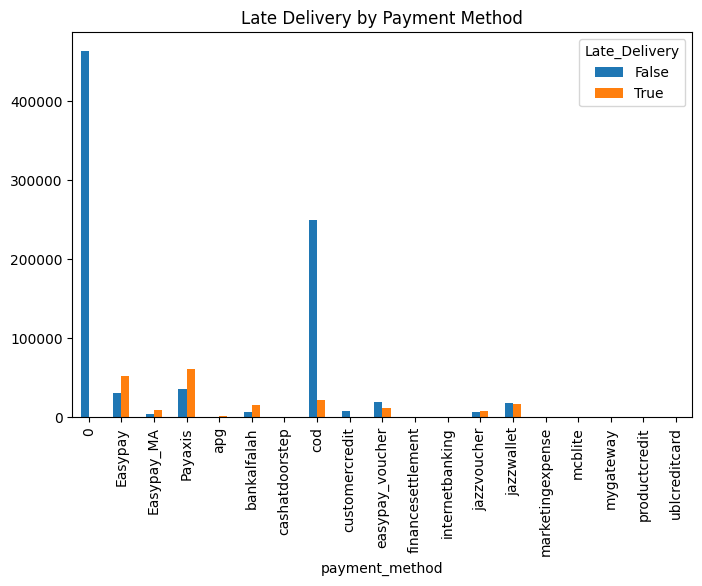

In [ ]:
group_pay = pd.crosstab(df["payment_method"], df["Late_Delivery"])

group_pay.plot(kind="bar", figsize=(8,5))
plt.title("Late Delivery by Payment Method")
plt.show()

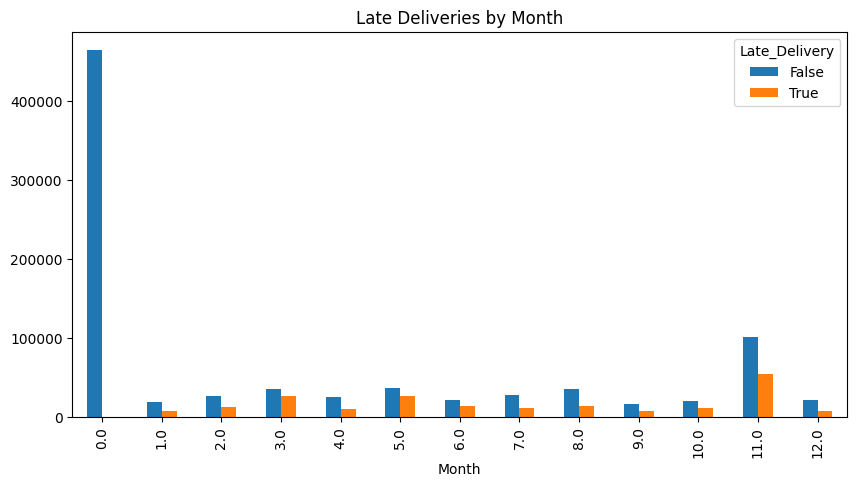

In [ ]:
month_delay = pd.crosstab(df["Month"], df["Late_Delivery"])

month_delay.plot(kind="bar", figsize=(10,5))
plt.title("Late Deliveries by Month")
plt.show()

**Which variable is the strongest predictor of heart disease, and how does the boxplot visualize this?**
Heart Disease

The strongest predictor of heart disease is typically chest pain type (cp) (in most analyses it shows the highest correlation with the target variable).

How the boxplot visualizes this:

The boxplot compares the distribution of variables (age and cholesterol) for patients with (1) and without (0) heart disease.

If the median line for target = 1 is higher, it shows that patients with heart disease generally have higher values.

The difference in spread and median between the two groups shows a clear separation, indicating that the variable is useful in identifying heart disease risk.

For example, the age boxplot often shows that older patients have a higher likelihood of heart disease.
**Based on your shipping analysis, what operational change might reduce late deliveries?**
. E-Commerce Shipping

The shipping analysis shows that late deliveries are higher for:

Certain product categories

Specific months (peak periods)

Large or high-value orders

Operational change to reduce delays:

The company should:

Improve logistics and inventory management for high-delay product categories

Increase staff or delivery capacity during peak months

Prioritize processing of large or high-risk orders

This would reduce operational bottlenecks and improve on-time delivery performance.


In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "heart_disease.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "oktayrdeki/heart-disease",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipython-input-419/3028972045.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'heart-disease' dataset.
First 5 records:     Age  Gender  Blood Pressure  Cholesterol Level Exercise Habits Smoking  \
0  56.0    Male           153.0              155.0            High     Yes   
1  69.0  Female           146.0              286.0            High      No   
2  46.0    Male           126.0              216.0             Low      No   
3  32.0  Female           122.0              293.0            High     Yes   
4  60.0    Male           166.0              242.0             Low     Yes   

  Family Heart Disease Diabetes        BMI High Blood Pressure  ...  \
0                  Yes       No  24.991591                 Yes  ...   
1                  Yes      Yes  25.221799                  No  ...   
2                   No       No  29.855447                  No  ...   
3                  Yes       No  24.130477                 Yes  ...   
4                  Yes      Yes  20.486289                 Yes  ...   

  High LDL Choleste

In [ ]:
import pandas as pd
from scipy import stats
# Group cholesterol values and drop NaN values
chol_disease = df[df['Heart Disease Status'] == 'Yes']['Cholesterol Level'].dropna()
chol_no_disease = df[df['Heart Disease Status'] == 'No']['Cholesterol Level'].dropna()

# Perform independent t-test
t_stat, p_val = stats.ttest_ind(chol_disease, chol_no_disease)

print("T-statistic:", t_stat)
print("P-value:", p_val)

# Decision
alpha = 0.05
if p_val < alpha:
    print("Reject H0: Cholesterol differs between groups")
else:
    print("Fail to reject H0: No significant difference")

T-statistic: 0.27054683306693134
P-value: 0.7867451935131643
Fail to reject H0: No significant difference


In [ ]:
!kaggle kernels pull komalkhetlani/world-happiness-report

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
import os
print(os.listdir())

['.config', 'drive', 'sample_data']


In [ ]:
import kagglehub
import pandas as pd
import os

# Download the dataset using kagglehub
# Using a more common and likely public World Happiness dataset
path = kagglehub.dataset_download("unsdsn/world-happiness")

# List files in the downloaded directory to find the correct CSV
print(f"Files in downloaded path: {os.listdir(path)}")

# Assuming the main data file is '2019.csv' or similar, you might need to adjust this
# Based on the previous cells, '2019.csv' was used for world happiness data.
df = pd.read_csv(os.path.join(path, "2019.csv"))

print("First 5 records:")
print(df.head())

Using Colab cache for faster access to the 'world-happiness' dataset.
Files in downloaded path: ['2015.csv', '2017.csv', '2019.csv', '2018.csv', '2016.csv']
First 5 records:
   Overall rank Country or region  Score  GDP per capita  Social support  \
0             1           Finland  7.769           1.340           1.587   
1             2           Denmark  7.600           1.383           1.573   
2             3            Norway  7.554           1.488           1.582   
3             4           Iceland  7.494           1.380           1.624   
4             5       Netherlands  7.488           1.396           1.522   

   Healthy life expectancy  Freedom to make life choices  Generosity  \
0                    0.986                         0.596       0.153   
1                    0.996                         0.592       0.252   
2                    1.028                         0.603       0.271   
3                    1.026                         0.591       0.354   
4        

In [ ]:
# Pearson correlation
corr_stat, p_val = stats.pearsonr(
    df['GDP per capita'],
    df['Score']
)

print("Correlation coefficient:", corr_stat)
print("P-value:", p_val)

# Decision
if p_val < 0.05:
    print("Reject H0: GDP is significantly correlated with Happiness")
else:
    print("Fail to reject H0: No significant correlation")

Correlation coefficient: 0.7938828678781275
P-value: 4.3154809133194095e-35
Reject H0: GDP is significantly correlated with Happiness


In [ ]:
import pandas as pd
import numpy as np

# Model tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier

# Encoding & preprocessing
from sklearn.preprocessing import LabelEncoder

# Visualization
import matplotlib.pyplot as plt